# Pré-processamento de Texto com spaCy

Este notebook demonstra técnicas de pré-processamento de texto em português usando:
- **spaCy** — lematização e remoção de stopwords
- **Stanza** — lematização alternativa
- **Enelvo** — normalização de texto

Usaremos um dataset fictício de descrições de projetos científicos em português.

## 1. Instalação das Bibliotecas

In [ ]:
# Instalar bibliotecas necessárias
!pip install spacy -q
!python -m spacy download pt_core_news_lg -q
!pip install stanza -q
!pip install enelvo -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.2/568.2 MB 2.5 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('pt_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 40.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 794.2/794.2 kB 50.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 48.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 31.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.9/240.9 kB 8.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.5/27.5 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 20.8 

## 2. Criação do Dataset Fictício

In [ ]:
import pandas as pd
import numpy as np

# Dataset fictício de projetos científicos brasileiros
dados = {
    'Título_Público': [
        'Desenvolvimento de vacina contra dengue',
        'Estudo sobre energias renováveis no Brasil',
        'Pesquisa em inteligência artificial para saúde',
        'Análise do desmatamento na Amazônia',
        'Desenvolvimento de antibióticos naturais',
        'Estudo do impacto das mudanças climáticas',
        'Pesquisa sobre biodiversidade do cerrado',
        'Desenvolvimento de materiais sustentáveis',
        'Análise genômica de doenças tropicais',
        'Estudo de novos combustíveis para aviação',
        'Pesquisa em robótica para agricultura',
        'Desenvolvimento de tratamentos para câncer',
        'Análise da qualidade da água em rios urbanos',
        'Pesquisa sobre alimentação saudável em crianças',
        'Estudo de novas tecnologias para educação'
    ],
    'Descricao_publica': [
        'Este projeto visa desenvolver uma vacina eficaz contra o vírus da dengue, utilizando técnicas modernas de biotecnologia. A pesquisa envolve o estudo das proteínas do vírus e a produção de anticorpos específicos para combater a doença. Espera-se reduzir significativamente os casos de dengue no Brasil nos próximos anos.',
        'O objetivo deste estudo é analisar o potencial das energias renováveis, como solar e eólica, para substituir os combustíveis fósseis no Brasil. A pesquisa busca identificar as regiões com maior potencial energético e propor políticas públicas para incentivar o uso de fontes limpas de energia.',
        'Esta pesquisa propõe o desenvolvimento de sistemas de inteligência artificial capazes de auxiliar médicos no diagnóstico de doenças. Utilizando algoritmos de aprendizado de máquina e redes neurais profundas, o sistema será treinado com milhares de imagens médicas para identificar padrões de doenças com alta precisão.',
        'O desmatamento na Amazônia é um problema grave que afeta o clima global e a biodiversidade. Este projeto monitora as áreas desmatadas utilizando imagens de satélite e técnicas de processamento de imagem. Os dados coletados ajudarão na criação de políticas de preservação mais eficazes.',
        'A resistência bacteriana aos antibióticos é uma ameaça crescente à saúde pública. Este projeto pesquisa compostos naturais encontrados em plantas medicinais brasileiras com potencial antibiótico. Os compostos serão testados em laboratório contra bactérias resistentes aos antibióticos convencionais.',
        'As mudanças climáticas estão causando impactos severos em todo o planeta. Esta pesquisa analisa os efeitos do aquecimento global no Brasil, incluindo o aumento das temperaturas, mudanças nos padrões de chuva e o impacto na agricultura. Os resultados servirão para orientar políticas de adaptação climática.',
        'O cerrado brasileiro é um dos biomas mais ricos em biodiversidade do mundo. Este projeto mapeia as espécies de plantas e animais do cerrado, identificando espécies ameaçadas de extinção. Os dados coletados serão usados para criar estratégias de conservação do bioma.',
        'Este projeto desenvolve novos materiais sustentáveis a partir de resíduos agroindustriais brasileiros. Os materiais produzidos serão testados para uso na construção civil e na indústria têxtil. O objetivo é reduzir o impacto ambiental e criar alternativas econômicas para os resíduos gerados.',
        'As doenças tropicais afetam milhões de pessoas no Brasil e no mundo. Esta pesquisa utiliza técnicas de genômica para identificar os genes responsáveis pela resistência a doenças como malária e leishmaniose. Os resultados poderão levar ao desenvolvimento de novos tratamentos mais eficazes.',
        'A aviação é responsável por uma parcela significativa das emissões de carbono no mundo. Este estudo pesquisa combustíveis alternativos, como biocombustíveis produzidos a partir de microalgas, para reduzir as emissões da aviação. Os combustíveis serão testados em condições reais de voo.',
        'A agricultura brasileira enfrenta desafios como a falta de mão de obra e a necessidade de aumentar a produtividade. Este projeto desenvolve robôs agrícolas capazes de plantar, irrigar e colher culturas de forma autônoma. Os robôs utilizam sensores e inteligência artificial para otimizar o trabalho no campo.',
        'O câncer é uma das principais causas de morte no Brasil. Esta pesquisa desenvolve novos tratamentos baseados em imunoterapia, que utiliza o próprio sistema imunológico do paciente para combater o tumor. Os tratamentos são testados em modelos animais antes de serem aplicados em humanos.',
        'A qualidade da água nos rios urbanos brasileiros está em declínio devido ao descarte irregular de esgoto e resíduos industriais. Este projeto monitora a qualidade da água em rios de grandes cidades, identificando os principais poluentes e suas fontes. Os dados coletados ajudarão na criação de políticas de saneamento mais eficazes.',
        'A alimentação inadequada na infância pode causar problemas de saúde ao longo da vida. Esta pesquisa analisa os hábitos alimentares de crianças brasileiras e propõe intervenções para melhorar a qualidade da dieta. O projeto envolve escolas públicas de diferentes regiões do Brasil.',
        'A educação tradicional enfrenta desafios para engajar os alunos no século XXI. Este projeto desenvolve ferramentas tecnológicas inovadoras, como realidade aumentada e jogos educativos, para tornar o aprendizado mais dinâmico e eficaz. As ferramentas serão testadas em escolas públicas e privadas.'
    ]
}

df = pd.DataFrame(dados)
print(f'Dataset criado com {len(df)} registros')
print(f'Colunas: {list(df.columns)}')
df.head()

Dataset criado com 15 registros
Colunas: ['Título_Público', 'Descricao_publica']


,Título_Público,Descricao_publica
0,Desenvolvimento de vacina contra dengue,Este projeto visa desenvolver uma vacina efica...
1,Estudo sobre energias renováveis no Brasil,O objetivo deste estudo é analisar o potencial...
2,Pesquisa em inteligência artificial para saúde,Esta pesquisa propõe o desenvolvimento de sist...
3,Análise do desmatamento na Amazônia,O desmatamento na Amazônia é um problema grave...
4,Desenvolvimento de antibióticos naturais,A resistência bacteriana aos antibióticos é um...


## 3. Configuração do spaCy com GPU

In [ ]:
import spacy
from spacy.lang.pt.stop_words import STOP_WORDS
import string

# Verificar se GPU está disponível
if spacy.prefer_gpu():
    print('✅ Usando GPU!')
else:
    print('⚠️ Usando CPU.')

# Carregar modelo de português
nlp = spacy.load('pt_core_news_lg')
print('✅ Modelo pt_core_news_lg carregado com sucesso!')

✅ Usando GPU!
✅ Modelo pt_core_news_lg carregado com sucesso!


## 4. Visualizando as Stopwords do Português

In [ ]:
# Visualizar algumas stopwords do português
stopwords = list(STOP_WORDS)
print(f'Total de stopwords em português: {len(stopwords)}')
print(f'\nAlgumas stopwords: {sorted(stopwords)[:30]}')

Total de stopwords em português: 416

Algumas stopwords: ['a', 'acerca', 'ademais', 'adeus', 'agora', 'ainda', 'algo', 'algumas', 'alguns', 'ali', 'além', 'ambas', 'ambos', 'antes', 'ao', 'aos', 'apenas', 'apoia', 'apoio', 'apontar', 'após', 'aquela', 'aquelas', 'aquele', 'aqueles', 'aqui', 'aquilo', 'as', 'assim', 'através']


## 5. Pré-processamento com spaCy

### 5.1 Testando em um texto individual

In [ ]:
# Pegar um texto de exemplo
texto_exemplo = df.iloc[0]['Descricao_publica']
print('TEXTO ORIGINAL:')
print(texto_exemplo)
print()

TEXTO ORIGINAL:
Este projeto visa desenvolver uma vacina eficaz contra o vírus da dengue, utilizando técnicas modernas de biotecnologia. A pesquisa envolve o estudo das proteínas do vírus e a produção de anticorpos específicos para combater a doença. Espera-se reduzir significativamente os casos de dengue no Brasil nos próximos anos.



In [ ]:
# Processar o texto com spaCy
pontuacao = string.punctuation
doc = nlp(texto_exemplo)

# Passo 1: Tokenização
print('TOKENS DO TEXTO:')
tokens = [token.text for token in doc]
print(tokens[:20], '...')
print(f'\nTotal de tokens: {len(tokens)}')

TOKENS DO TEXTO:
['Este', 'projeto', 'visa', 'desenvolver', 'uma', 'vacina', 'eficaz', 'contra', 'o', 'vírus', 'da', 'dengue', ',', 'utilizando', 'técnicas', 'modernas', 'de', 'biotecnologia', '.', 'A'] ...

Total de tokens: 52


In [ ]:
# Passo 2: Remover stopwords e pontuação
tokens_limpos = [
    token for token in doc
    if token.text.lower() not in STOP_WORDS
    and token.text not in pontuacao
    and not token.is_space
]

print('TOKENS APÓS REMOÇÃO DE STOPWORDS E PONTUAÇÃO:')
print([token.text for token in tokens_limpos])
print(f'\nTotal de tokens após limpeza: {len(tokens_limpos)}')
print(f'Tokens removidos: {len(tokens) - len(tokens_limpos)}')

TOKENS APÓS REMOÇÃO DE STOPWORDS E PONTUAÇÃO:
['projeto', 'visa', 'desenvolver', 'vacina', 'eficaz', 'vírus', 'dengue', 'utilizando', 'técnicas', 'modernas', 'biotecnologia', 'pesquisa', 'envolve', 'estudo', 'proteínas', 'vírus', 'produção', 'anticorpos', 'específicos', 'combater', 'doença', 'Espera-se', 'reduzir', 'significativamente', 'casos', 'dengue', 'Brasil', 'próximos', 'anos']

Total de tokens após limpeza: 29
Tokens removidos: 23


In [ ]:
# Passo 3: Lematização
texto_lemmatizado = ' '.join([token.lemma_ for token in tokens_limpos])

print('TEXTO ORIGINAL:')
print(texto_exemplo)
print()
print('TEXTO LEMATIZADO (spaCy):')
print(texto_lemmatizado)

TEXTO ORIGINAL:
Este projeto visa desenvolver uma vacina eficaz contra o vírus da dengue, utilizando técnicas modernas de biotecnologia. A pesquisa envolve o estudo das proteínas do vírus e a produção de anticorpos específicos para combater a doença. Espera-se reduzir significativamente os casos de dengue no Brasil nos próximos anos.

TEXTO LEMATIZADO (spaCy):
projeto visar desenvolver vacina eficaz vírus dengue utilizar técnica moderno biotecnologia pesquisa envolver estudo proteína vírus produção anticorpo específico combater doença Espera-se reduzir significativamente caso dengue Brasil próximo ano


### 5.2 Função de pré-processamento completa

In [ ]:
def preprocessar_spacy(texto):
    """
    Função que aplica pré-processamento completo com spaCy:
    - Remove stopwords
    - Remove pontuação
    - Lematiza os tokens restantes
    """
    doc = nlp(texto)
    tokens_limpos = [
        token for token in doc
        if token.text.lower() not in STOP_WORDS
        and token.text not in string.punctuation
        and not token.is_space
    ]
    return ' '.join([token.lemma_ for token in tokens_limpos])

# Aplicar em todo o dataset
print('Processando textos com spaCy...')
df['texto_spacy'] = df['Descricao_publica'].apply(preprocessar_spacy)
print('✅ Processamento concluído!')
df[['Título_Público', 'texto_spacy']].head()

Processando textos com spaCy...
✅ Processamento concluído!


,Título_Público,texto_spacy
0,Desenvolvimento de vacina contra dengue,projeto visar desenvolver vacina eficaz vírus ...
1,Estudo sobre energias renováveis no Brasil,objetivo estudo analisar potencial energia ren...
2,Pesquisa em inteligência artificial para saúde,pesquisa propor desenvolvimento sistema inteli...
3,Análise do desmatamento na Amazônia,desmatamento Amazônia problema grave afetar cl...
4,Desenvolvimento de antibióticos naturais,resistência bacteriano antibiótico ameaça cres...


## 6. Pré-processamento com Stanza

In [ ]:
import stanza

# Baixar modelo português
stanza.download('pt')

# Criar pipeline
nlp_stanza = stanza.Pipeline('pt', processors='tokenize,mwt,pos,lemma')
print('✅ Stanza configurado!')

INFO:stanza:Downloaded file to /root/.cache/stanza/1.13.0/resources/resources.json
INFO:stanza:Downloading default packages for language: pt (Portuguese) ...
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


models/default.zip:   0%|          | 0.00/404M [00:00<?, ?B/s]

INFO:stanza:Downloaded file to /root/.cache/stanza/1.13.0/resources/pt/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.13.0/resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.13.0/resources/resources.json
INFO:stanza:Loading these models for language: pt (Portuguese):
| Processor | Package         |
-------------------------------
| tokenize  | bosque          |
| mwt       | bosque          |
| pos       | bosque_charlm   |
| lemma     | bosque_nocharlm |

INFO:stanza:Using device: cuda
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Loading: lemma
INFO:stanza:Done loading processors!


✅ Stanza configurado!


In [ ]:
def preprocessar_stanza(texto):
    """
    Função que aplica pré-processamento com Stanza:
    - Lematiza todos os tokens
    """
    doc = nlp_stanza(texto)
    lemmas = [
        word.lemma for sent in doc.sentences
        for word in sent.words
        if word.text.lower() not in STOP_WORDS
        and word.text not in string.punctuation
    ]
    return ' '.join(lemmas)

# Testar em um texto
print('TEXTO ORIGINAL:')
print(texto_exemplo)
print()
print('TEXTO LEMATIZADO (Stanza):')
print(preprocessar_stanza(texto_exemplo))

TEXTO ORIGINAL:
Este projeto visa desenvolver uma vacina eficaz contra o vírus da dengue, utilizando técnicas modernas de biotecnologia. A pesquisa envolve o estudo das proteínas do vírus e a produção de anticorpos específicos para combater a doença. Espera-se reduzir significativamente os casos de dengue no Brasil nos próximos anos.

TEXTO LEMATIZADO (Stanza):
projeto visar desenvolver vacina eficaz vírus dengue utilizar técnica moderno biotecnologia pesquisa envolver estudo proteína vírus produção anticorpo específico combater doença esperar reduzir significativamente caso dengue Brasil próximo ano


In [ ]:
# Aplicar em todo o dataset
print('Processando textos com Stanza (pode demorar um pouco)...')
df['texto_stanza'] = df['Descricao_publica'].apply(preprocessar_stanza)
print('✅ Processamento concluído!')

Processando textos com Stanza (pode demorar um pouco)...
✅ Processamento concluído!


## 7. Normalização com Enelvo

In [ ]:
from enelvo.normaliser import Normaliser

# Criar normalizador
norm = Normaliser(tokenizer='readable')

def preprocessar_enelvo(texto):
    """
    Função que aplica normalização com Enelvo
    """
    return ' '.join([norm.normalise(palavra) for palavra in texto.split()])

# Testar em um texto
print('TEXTO ORIGINAL:')
print(texto_exemplo)
print()
print('TEXTO NORMALIZADO (Enelvo):')
print(preprocessar_enelvo(texto_exemplo))

TEXTO ORIGINAL:
Este projeto visa desenvolver uma vacina eficaz contra o vírus da dengue, utilizando técnicas modernas de biotecnologia. A pesquisa envolve o estudo das proteínas do vírus e a produção de anticorpos específicos para combater a doença. Espera-se reduzir significativamente os casos de dengue no Brasil nos próximos anos.

TEXTO NORMALIZADO (Enelvo):
este projeto visa desenvolver uma vacina eficaz contra o vírus da dengue , utilizando técnicas modernas de biotecnologia . a pesquisa envolve o estudo das proteínas do vírus e a produção de anticorpos específicos para combater a doença . espera-se reduzir significativamente os casos de dengue no brasil nos próximos anos .


In [ ]:
# Aplicar em todo o dataset
print('Normalizando textos com Enelvo...')
df['texto_enelvo'] = df['Descricao_publica'].apply(preprocessar_enelvo)
print('✅ Normalização concluída!')

Normalizando textos com Enelvo...
✅ Normalização concluída!


## 8. Comparação dos Três Métodos

In [ ]:
# Comparar os três métodos no primeiro texto
print('=' * 80)
print('COMPARAÇÃO DOS MÉTODOS DE PRÉ-PROCESSAMENTO')
print('=' * 80)
print()
print('📌 TEXTO ORIGINAL:')
print(df.iloc[0]['Descricao_publica'])
print()
print('-' * 80)
print('🔵 spaCy (Lematização + Remoção de Stopwords):')
print(df.iloc[0]['texto_spacy'])
print()
print('-' * 80)
print('🟢 Stanza (Lematização + Remoção de Stopwords):')
print(df.iloc[0]['texto_stanza'])
print()
print('-' * 80)
print('🟡 Enelvo (Normalização):')
print(df.iloc[0]['texto_enelvo'])
print('=' * 80)

COMPARAÇÃO DOS MÉTODOS DE PRÉ-PROCESSAMENTO

📌 TEXTO ORIGINAL:
Este projeto visa desenvolver uma vacina eficaz contra o vírus da dengue, utilizando técnicas modernas de biotecnologia. A pesquisa envolve o estudo das proteínas do vírus e a produção de anticorpos específicos para combater a doença. Espera-se reduzir significativamente os casos de dengue no Brasil nos próximos anos.

--------------------------------------------------------------------------------
🔵 spaCy (Lematização + Remoção de Stopwords):
projeto visar desenvolver vacina eficaz vírus dengue utilizar técnica moderno biotecnologia pesquisa envolver estudo proteína vírus produção anticorpo específico combater doença Espera-se reduzir significativamente caso dengue Brasil próximo ano

--------------------------------------------------------------------------------
🟢 Stanza (Lematização + Remoção de Stopwords):
projeto visar desenvolver vacina eficaz vírus dengue utilizar técnica moderno biotecnologia pesquisa envolver estu

## 9. Análise dos Resultados

In [ ]:
# Comparar tamanho dos textos antes e depois do processamento
df['tokens_original'] = df['Descricao_publica'].apply(lambda x: len(x.split()))
df['tokens_spacy'] = df['texto_spacy'].apply(lambda x: len(x.split()))
df['tokens_stanza'] = df['texto_stanza'].apply(lambda x: len(x.split()))
df['tokens_enelvo'] = df['texto_enelvo'].apply(lambda x: len(x.split()))

print('MÉDIA DE TOKENS POR TEXTO:')
print(f'  Original : {df["tokens_original"].mean():.1f} tokens')
print(f'  spaCy    : {df["tokens_spacy"].mean():.1f} tokens')
print(f'  Stanza   : {df["tokens_stanza"].mean():.1f} tokens')
print(f'  Enelvo   : {df["tokens_enelvo"].mean():.1f} tokens')

reducao_spacy = (1 - df['tokens_spacy'].mean() / df['tokens_original'].mean()) * 100
reducao_stanza = (1 - df['tokens_stanza'].mean() / df['tokens_original'].mean()) * 100
print()
print('REDUÇÃO DE TOKENS:')
print(f'  spaCy  : {reducao_spacy:.1f}% de redução')
print(f'  Stanza : {reducao_stanza:.1f}% de redução')

MÉDIA DE TOKENS POR TEXTO:
  Original : 43.6 tokens
  spaCy    : 25.7 tokens
  Stanza   : 25.7 tokens
  Enelvo   : 47.4 tokens

REDUÇÃO DE TOKENS:
  spaCy  : 41.0% de redução
  Stanza : 41.0% de redução


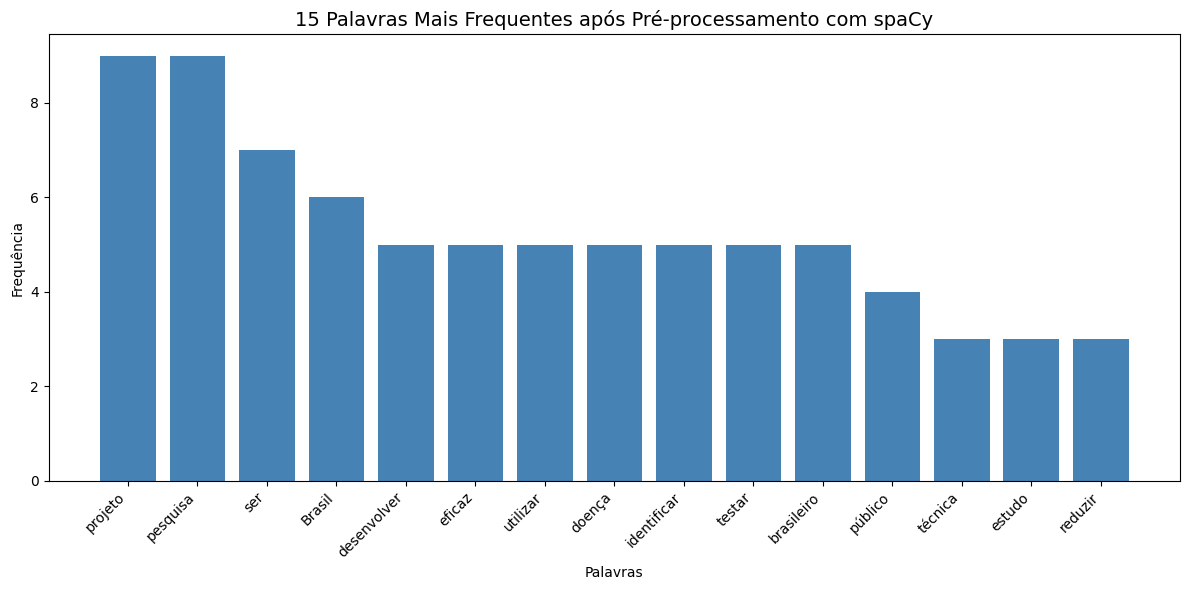


Top 15 palavras mais frequentes:
  projeto: 9
  pesquisa: 9
  ser: 7
  Brasil: 6
  desenvolver: 5
  eficaz: 5
  utilizar: 5
  doença: 5
  identificar: 5
  testar: 5
  brasileiro: 5
  público: 4
  técnica: 3
  estudo: 3
  reduzir: 3


In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Palavras mais frequentes após pré-processamento com spaCy
todos_tokens = ' '.join(df['texto_spacy'].tolist()).split()
frequencia = Counter(todos_tokens)
palavras_mais_comuns = frequencia.most_common(15)

palavras = [item[0] for item in palavras_mais_comuns]
contagens = [item[1] for item in palavras_mais_comuns]

plt.figure(figsize=(12, 6))
plt.bar(palavras, contagens, color='steelblue')
plt.title('15 Palavras Mais Frequentes após Pré-processamento com spaCy', fontsize=14)
plt.xlabel('Palavras')
plt.ylabel('Frequência')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('\nTop 15 palavras mais frequentes:')
for palavra, contagem in palavras_mais_comuns:
    print(f'  {palavra}: {contagem}')

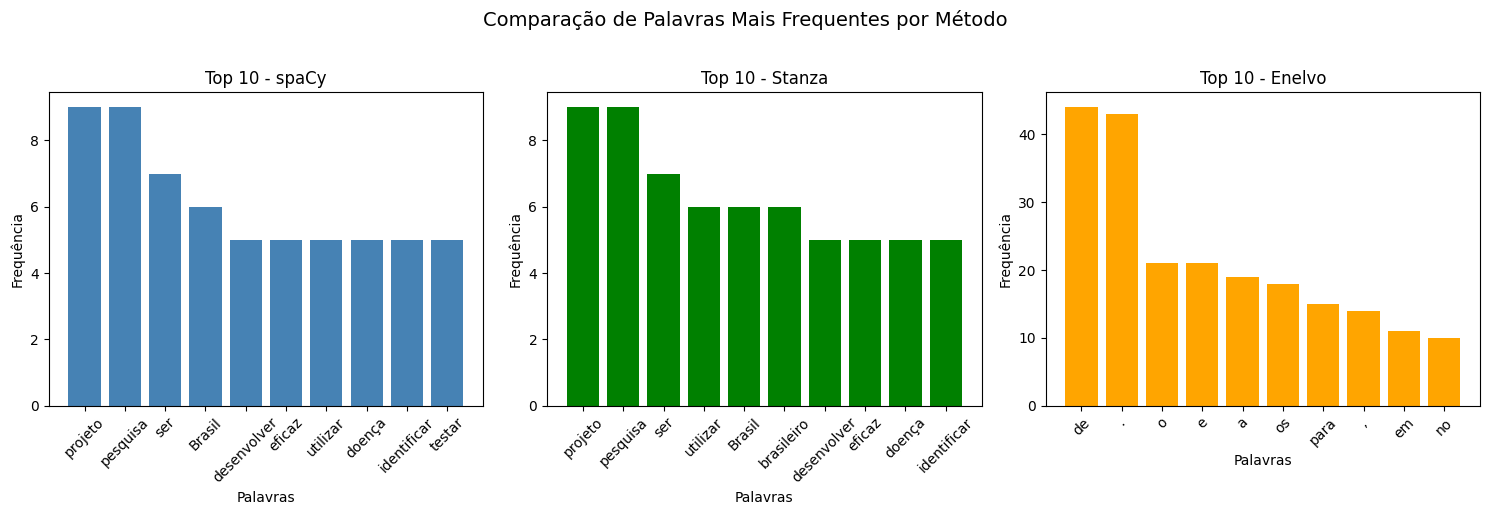

In [ ]:
# Comparação visual entre os métodos
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metodos = [
    ('texto_spacy', 'spaCy', 'steelblue'),
    ('texto_stanza', 'Stanza', 'green'),
    ('texto_enelvo', 'Enelvo', 'orange')
]

for ax, (coluna, titulo, cor) in zip(axes, metodos):
    tokens = ' '.join(df[coluna].tolist()).split()
    freq = Counter(tokens).most_common(10)
    palavras = [item[0] for item in freq]
    contagens = [item[1] for item in freq]
    ax.bar(palavras, contagens, color=cor)
    ax.set_title(f'Top 10 - {titulo}', fontsize=12)
    ax.set_xlabel('Palavras')
    ax.set_ylabel('Frequência')
    ax.tick_params(axis='x', rotation=45)

plt.suptitle('Comparação de Palavras Mais Frequentes por Método', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Dataset Final Processado

In [ ]:
# Visualizar dataset final
colunas_finais = ['Título_Público', 'Descricao_publica', 'texto_spacy', 'texto_stanza', 'texto_enelvo']
df_final = df[colunas_finais]

print('DATASET FINAL COM TODOS OS PRÉ-PROCESSAMENTOS:')
print(f'Shape: {df_final.shape}')
df_final.head()

DATASET FINAL COM TODOS OS PRÉ-PROCESSAMENTOS:
Shape: (15, 5)


,Título_Público,Descricao_publica,texto_spacy,texto_stanza,texto_enelvo
0,Desenvolvimento de vacina contra dengue,Este projeto visa desenvolver uma vacina efica...,projeto visar desenvolver vacina eficaz vírus ...,projeto visar desenvolver vacina eficaz vírus ...,este projeto visa desenvolver uma vacina efica...
1,Estudo sobre energias renováveis no Brasil,O objetivo deste estudo é analisar o potencial...,objetivo estudo analisar potencial energia ren...,objetivo estudo analisar potencial energia ren...,o objetivo deste estudo é analisar o potencial...
2,Pesquisa em inteligência artificial para saúde,Esta pesquisa propõe o desenvolvimento de sist...,pesquisa propor desenvolvimento sistema inteli...,pesquisa propor desenvolvimento sistema inteli...,esta pesquisa propõe o desenvolvimento de sist...
3,Análise do desmatamento na Amazônia,O desmatamento na Amazônia é um problema grave...,desmatamento Amazônia problema grave afetar cl...,desmatamento Amazônia problema grave afetar cl...,o desmatamento na amazônia é um problema grave...
4,Desenvolvimento de antibióticos naturais,A resistência bacteriana aos antibióticos é um...,resistência bacteriano antibiótico ameaça cres...,resistência bacteriano antibiótico ameaça cres...,a resistência bacteriana aos antibióticos é um...


In [ ]:
# Salvar dataset processado
df_final.to_csv('dataset_preprocessado.csv', index=False, encoding='utf-8-sig')
print('✅ Dataset salvo como dataset_preprocessado.csv')

# Fazer download do arquivo
from google.colab import files
files.download('dataset_preprocessado.csv')

✅ Dataset salvo como dataset_preprocessado.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 11. Resumo Final

### O que foi feito:
| Etapa | Descrição |
|-------|----------|
| **Dataset** | 15 descrições fictícias de projetos científicos em português |
| **spaCy** | Remoção de stopwords + pontuação + lematização |
| **Stanza** | Remoção de stopwords + pontuação + lematização alternativa |
| **Enelvo** | Normalização do texto |
| **Análise** | Comparação de frequências e redução de tokens |

### Principais diferenças entre os métodos:
- **spaCy**: mais rápido, ideal para grandes volumes de texto
- **Stanza**: mais preciso linguisticamente, porém mais lento
- **Enelvo**: focado em normalização (corrigir gírias, abreviações)